# Campus Wall Decoration — DINOv2 Baseline

DINOv2-only baseline for `wall_type` and `indoor` classification


In [1]:
# ============================================================
# 1. INSTALL + IMPORTS
# ============================================================

!pip -q install torch torchvision scikit-learn pandas numpy matplotlib seaborn pillow

import os
import glob
import random
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms

from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.utils.class_weight import compute_class_weight
from sklearn.model_selection import GroupKFold
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix

from PIL import Image

warnings.filterwarnings("ignore")

RANDOM_SEED = 42
random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)
torch.manual_seed(RANDOM_SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", DEVICE)


Device: cpu


In [2]:
# ============================================================
# 2. CONFIG
# ============================================================

from google.colab import drive
drive.mount('/content/drive')

SPLITS_FOLDER = "/content/drive/MyDrive/SoftCom Project/Dataset"
RAW_IMAGES_FOLDER = "/content/drive/MyDrive/Wall decoration images"
OUTPUT_FOLDER = "/content/drive/MyDrive/SoftCom Project/Dataset/Baseline_Results/DINOv2"
os.makedirs(OUTPUT_FOLDER, exist_ok=True)

# DINOv2 ViT variants (bigger = better features, slower, more memory):
#   dinov2_vits14 -> embed_dim 384   (fastest, good default for a small dataset)
#   dinov2_vitb14 -> embed_dim 768
#   dinov2_vitl14 -> embed_dim 1024
#   dinov2_vitg14 -> embed_dim 1536  (needs a strong GPU)
DINOV2_MODEL_NAME = "dinov2_vits14"

IMAGE_SIZE = (224, 224)   # 224 is divisible by DINOv2's patch size (14) -- required
IMAGENET_MEAN = (0.485, 0.456, 0.406)
IMAGENET_STD = (0.229, 0.224, 0.225)

BATCH_SIZE = 16
LINEAR_HEAD_EPOCHS = 30
LINEAR_HEAD_LR = 1e-3

TASKS = {"wall_type": "multiclass", "indoor": "binary"}


Mounted at /content/drive


## Load splits, resolve image paths, merge train+val




In [3]:
# ============================================================
# 3. LOAD SPLITS + RESOLVE PATHS
# ============================================================

def load_split(name):
    path = os.path.join(SPLITS_FOLDER, name)
    if not os.path.exists(path):
        raise FileNotFoundError(f"Could not find {path}\nCheck SPLITS_FOLDER in the CONFIG cell.")
    df = pd.read_csv(path, encoding="utf-8-sig")
    keep = ["image_id", "wall_type", "indoor", "description_en", "description_bn", "color_idea", "group_id"]
    return df[[c for c in keep if c in df.columns]].copy()

EXTENSIONS = [".jpg", ".jpeg", ".JPG", ".JPEG", ".png", ".PNG", ".webp", ".WEBP"]

def resolve_image_path(image_id):
    for ext in EXTENSIONS:
        candidate = os.path.join(RAW_IMAGES_FOLDER, image_id + ext)
        if os.path.exists(candidate):
            return candidate
    matches = glob.glob(os.path.join(RAW_IMAGES_FOLDER, image_id + ".*"))
    return matches[0] if matches else None

def attach_image_paths(df):
    df = df.copy()
    df["image_path"] = df["image_id"].apply(resolve_image_path)
    missing = df[df["image_path"].isna()]
    if len(missing) > 0:
        print(f"⚠️  {len(missing)} images not found, dropped: {missing['image_id'].tolist()}")
    return df[df["image_path"].notna()].reset_index(drop=True)

train_df = attach_image_paths(load_split("train.csv"))
val_df   = attach_image_paths(load_split("validation.csv"))
test_df  = attach_image_paths(load_split("test.csv"))

for d in (train_df, val_df, test_df):
    d["indoor"] = pd.to_numeric(d["indoor"], errors="coerce").astype(int)

train_pool_df = pd.concat([train_df, val_df], ignore_index=True)
print("Train pool:", len(train_pool_df), "| Test (held out):", len(test_df))

wall_type_encoder = LabelEncoder().fit(train_pool_df["wall_type"])
for d in (train_pool_df, test_df):
    d["wall_type_label"] = wall_type_encoder.transform(d["wall_type"])

WALL_TYPE_CLASSES = list(wall_type_encoder.classes_)
NUM_CLASSES = {"wall_type": len(WALL_TYPE_CLASSES), "indoor": 2}
TARGET_COLUMN = {"wall_type": "wall_type_label", "indoor": "indoor"}
print("wall_type classes:", WALL_TYPE_CLASSES)


Train pool: 264 | Test (held out): 24
wall_type classes: ['backdrop_board', 'brick_wall', 'bulletin_board', 'painted_wall', 'wooden_wall']


In [4]:
# ============================================================
# 4. DATASET (image-only -- no label needed for embedding extraction)
# ============================================================

eval_transform = transforms.Compose([
    transforms.Resize(IMAGE_SIZE),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])

class ImageOnlyDataset(Dataset):
    """Yields (image_tensor, image_id) -- decoupled from any task label,
    so the same embeddings can be reused across wall_type, indoor, color_idea, etc."""
    def __init__(self, dataframe, transform=None):
        self.df = dataframe.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        with Image.open(row["image_path"]) as img:
            image = img.convert("RGB")
        if self.transform is not None:
            image = self.transform(image)
        return image, row["image_id"]


## Load DINOv2 and extract embeddings once per image




In [5]:
# ============================================================
# 5. LOAD DINOv2 + EXTRACT + CACHE EMBEDDINGS
# ============================================================

dinov2_model = torch.hub.load("facebookresearch/dinov2", DINOV2_MODEL_NAME)
dinov2_model = dinov2_model.to(DEVICE).eval()
EMBED_DIM = dinov2_model.embed_dim
print(f"Loaded {DINOV2_MODEL_NAME}, embed_dim={EMBED_DIM}")


@torch.no_grad()
def extract_embeddings(model, dataframe, batch_size=16):
    """Returns {image_id: embedding_vector}. Independent of any task/label."""
    dataset = ImageOnlyDataset(dataframe, transform=eval_transform)
    loader = DataLoader(dataset, batch_size=batch_size, shuffle=False, num_workers=2)
    embeddings = {}
    for images, image_ids in loader:
        feats = model.forward_features(images.to(DEVICE))["x_norm_clstoken"]
        feats = feats.cpu().numpy()
        for image_id, vec in zip(image_ids, feats):
            embeddings[image_id] = vec
    return embeddings


all_images_df = pd.concat([train_pool_df, test_df], ignore_index=True).drop_duplicates(subset="image_id")
embedding_lookup = extract_embeddings(dinov2_model, all_images_df, BATCH_SIZE)
print(f"Extracted embeddings for {len(embedding_lookup)} images")

# --- cache to disk for reuse in Phase 6 (color_idea) / Phase 10 (recommendation engine) ---
image_ids_sorted = sorted(embedding_lookup.keys())
embedding_matrix = np.stack([embedding_lookup[iid] for iid in image_ids_sorted])
np.savez(
    os.path.join(OUTPUT_FOLDER, f"dinov2_embeddings_{DINOV2_MODEL_NAME}.npz"),
    image_ids=np.array(image_ids_sorted),
    embeddings=embedding_matrix,
)
print("Cached embeddings ->", os.path.join(OUTPUT_FOLDER, f"dinov2_embeddings_{DINOV2_MODEL_NAME}.npz"))
print("To reuse later:  data = np.load(path); ids = data['image_ids']; X = data['embeddings']")


Downloading: "https://github.com/facebookresearch/dinov2/zipball/main" to /root/.cache/torch/hub/main.zip
Downloading: "https://dl.fbaipublicfiles.com/dinov2/dinov2_vits14/dinov2_vits14_pretrain.pth" to /root/.cache/torch/hub/checkpoints/dinov2_vits14_pretrain.pth


100%|██████████| 84.2M/84.2M [00:00<00:00, 168MB/s]


Loaded dinov2_vits14, embed_dim=384
Extracted embeddings for 288 images
Cached embeddings -> /content/drive/MyDrive/SoftCom Project/Dataset/Baseline_Results/DINOv2/dinov2_embeddings_dinov2_vits14.npz
To reuse later:  data = np.load(path); ids = data['image_ids']; X = data['embeddings']


In [6]:
# ============================================================
# 6. BUILD (X, y) PER TASK FROM CACHED EMBEDDINGS
# ============================================================

def get_features_and_labels(dataframe, target_column):
    X = np.stack([embedding_lookup[iid] for iid in dataframe["image_id"]])
    y = dataframe[target_column].values
    return X, y


## Naive baseline

In [7]:
# ============================================================
# 7. NAIVE MAJORITY-CLASS BASELINE
# ============================================================

results = []

for task in TASKS:
    target_column = TARGET_COLUMN[task]
    majority_class = train_pool_df[target_column].mode()[0]
    y_true = test_df[target_column].values
    y_pred = np.full_like(y_true, fill_value=majority_class)
    acc = accuracy_score(y_true, y_pred)
    f1_macro = f1_score(y_true, y_pred, average="macro", zero_division=0)
    results.append({"task": task, "method": "naive_majority", "accuracy": acc, "macro_f1": f1_macro})
    print(f"[naive] {task:10s} test acc={acc:.3f} macro_f1={f1_macro:.3f}")


[naive] wall_type  test acc=0.458 macro_f1=0.126
[naive] indoor     test acc=0.792 macro_f1=0.442


## Baseline — DINOv2 frozen features + classical classifiers

In [8]:
# ============================================================
# 8. CLASSICAL CLASSIFIERS ON DINOv2 FEATURES
# ============================================================

def get_classical_classifiers():
    return {
        "logreg": LogisticRegression(max_iter=2000, class_weight="balanced", random_state=RANDOM_SEED),
        "linear_svm": SVC(kernel="linear", class_weight="balanced", random_state=RANDOM_SEED),
        "knn": KNeighborsClassifier(n_neighbors=5),
    }

for task in TASKS:
    target_column = TARGET_COLUMN[task]
    X_train, y_train = get_features_and_labels(train_pool_df, target_column)
    X_test,  y_test  = get_features_and_labels(test_df, target_column)
    print(f"\n{task}: train {X_train.shape}, test {X_test.shape}")

    for clf_name, clf in get_classical_classifiers().items():
        clf.fit(X_train, y_train)
        y_pred = clf.predict(X_test)
        acc = accuracy_score(y_test, y_pred)
        f1_macro = f1_score(y_test, y_pred, average="macro", zero_division=0)
        results.append({"task": task, "method": f"frozen_dinov2_{clf_name}", "accuracy": acc, "macro_f1": f1_macro})
        print(f"  [frozen+{clf_name:10s}] acc={acc:.3f} macro_f1={f1_macro:.3f}")



wall_type: train (264, 384), test (24, 384)
  [frozen+logreg    ] acc=0.625 macro_f1=0.573
  [frozen+linear_svm] acc=0.500 macro_f1=0.458
  [frozen+knn       ] acc=0.458 macro_f1=0.406

indoor: train (264, 384), test (24, 384)
  [frozen+logreg    ] acc=0.917 macro_f1=0.874
  [frozen+linear_svm] acc=0.917 macro_f1=0.874
  [frozen+knn       ] acc=0.833 macro_f1=0.700


## Optional — trainable linear head on frozen DINOv2 features (PyTorch)



In [9]:
# ============================================================
# 9. TRAINABLE LINEAR HEAD ON FROZEN FEATURES
# ============================================================

def train_linear_head(task):
    target_column = TARGET_COLUMN[task]
    num_classes = NUM_CLASSES[task]

    X_train, y_train = get_features_and_labels(train_pool_df, target_column)
    X_test,  y_test  = get_features_and_labels(test_df, target_column)

    X_train_t = torch.tensor(X_train, dtype=torch.float32).to(DEVICE)
    y_train_t = torch.tensor(y_train, dtype=torch.long).to(DEVICE)
    X_test_t  = torch.tensor(X_test,  dtype=torch.float32).to(DEVICE)
    y_test_t  = torch.tensor(y_test,  dtype=torch.long).to(DEVICE)

    class_weights = compute_class_weight("balanced", classes=np.arange(num_classes), y=y_train)
    class_weights = torch.tensor(class_weights, dtype=torch.float32).to(DEVICE)

    head = nn.Linear(EMBED_DIM, num_classes).to(DEVICE)
    criterion = nn.CrossEntropyLoss(weight=class_weights)
    optimizer = torch.optim.AdamW(head.parameters(), lr=LINEAR_HEAD_LR)

    for epoch in range(1, LINEAR_HEAD_EPOCHS + 1):
        head.train()
        optimizer.zero_grad()
        loss = criterion(head(X_train_t), y_train_t)
        loss.backward()
        optimizer.step()
        if epoch % 10 == 0 or epoch == LINEAR_HEAD_EPOCHS:
            print(f"  [{task}] epoch {epoch:02d}/{LINEAR_HEAD_EPOCHS} loss={loss.item():.3f}")

    head.eval()
    with torch.no_grad():
        preds = head(X_test_t).argmax(dim=1).cpu().numpy()
    acc = accuracy_score(y_test, preds)
    f1_macro = f1_score(y_test, preds, average="macro", zero_division=0)
    print(f"  -> TEST acc={acc:.3f} macro_f1={f1_macro:.3f}")
    return head, acc, f1_macro


linear_heads = {}
for task in TASKS:
    print(f"\n=== Training linear head on frozen DINOv2 features: {task} ===")
    head, acc, f1_macro = train_linear_head(task)
    linear_heads[task] = head
    results.append({"task": task, "method": "frozen_dinov2_linear_head", "accuracy": acc, "macro_f1": f1_macro})



=== Training linear head on frozen DINOv2 features: wall_type ===
  [wall_type] epoch 10/30 loss=0.895
  [wall_type] epoch 20/30 loss=0.510
  [wall_type] epoch 30/30 loss=0.334
  -> TEST acc=0.667 macro_f1=0.660

=== Training linear head on frozen DINOv2 features: indoor ===
  [indoor] epoch 10/30 loss=0.304
  [indoor] epoch 20/30 loss=0.151
  [indoor] epoch 30/30 loss=0.089
  -> TEST acc=0.917 macro_f1=0.889


## Results table + confusion matrices

,task,method,accuracy,macro_f1
9,indoor,frozen_dinov2_linear_head,0.916667,0.888889
5,indoor,frozen_dinov2_logreg,0.916667,0.873684
6,indoor,frozen_dinov2_linear_svm,0.916667,0.873684
7,indoor,frozen_dinov2_knn,0.833333,0.700000
1,indoor,naive_majority,0.791667,0.441860
8,wall_type,frozen_dinov2_linear_head,0.666667,0.660000
2,wall_type,frozen_dinov2_logreg,0.625000,0.573333
3,wall_type,frozen_dinov2_linear_svm,0.500000,0.457990
4,wall_type,frozen_dinov2_knn,0.458333,0.406433
0,wall_type,naive_majority,0.458333,0.125714


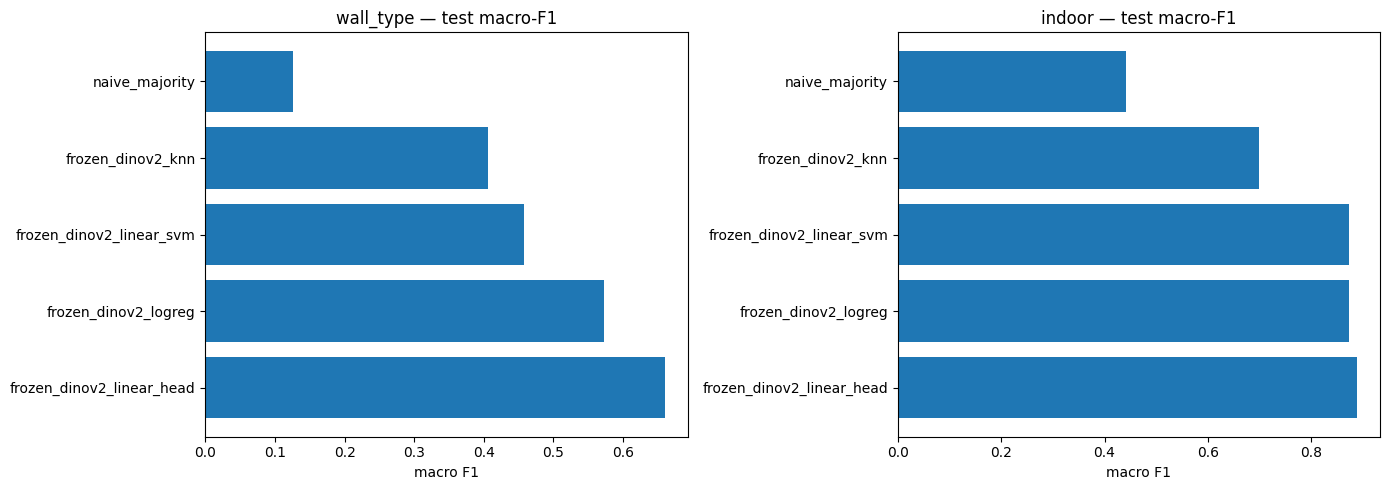

In [10]:
# ============================================================
# 10. RESULTS TABLE
# ============================================================

results_df = pd.DataFrame(results).sort_values(["task", "macro_f1"], ascending=[True, False])
results_df.to_csv(os.path.join(OUTPUT_FOLDER, "dinov2_baseline_results.csv"), index=False)
display(results_df)

fig, axes = plt.subplots(1, len(TASKS), figsize=(7 * len(TASKS), 5))
for ax, task in zip(axes, TASKS):
    sub = results_df[results_df["task"] == task]
    ax.barh(sub["method"], sub["macro_f1"])
    ax.set_title(f"{task} — test macro-F1")
    ax.set_xlabel("macro F1")
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_FOLDER, "dinov2_baseline_comparison.png"), dpi=150)
plt.show()


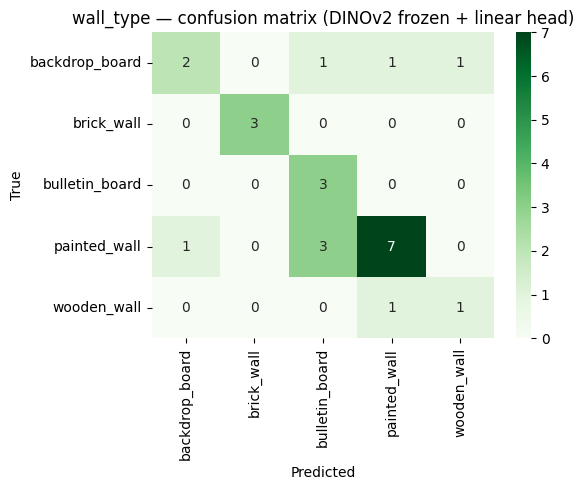


wall_type classification report (DINOv2 frozen + linear head):
                precision    recall  f1-score   support

backdrop_board       0.67      0.40      0.50         5
    brick_wall       1.00      1.00      1.00         3
bulletin_board       0.43      1.00      0.60         3
  painted_wall       0.78      0.64      0.70        11
   wooden_wall       0.50      0.50      0.50         2

      accuracy                           0.67        24
     macro avg       0.67      0.71      0.66        24
  weighted avg       0.72      0.67      0.67        24



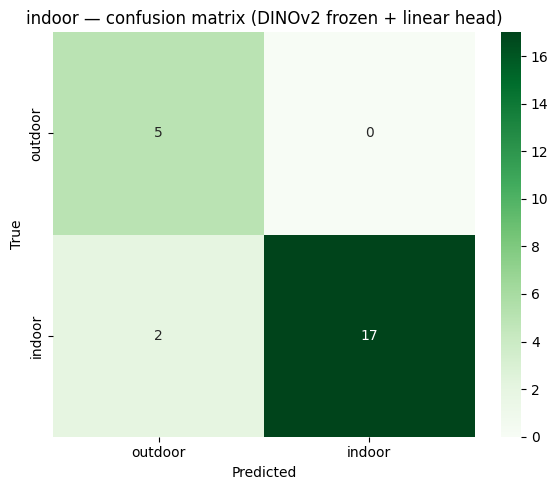


indoor classification report (DINOv2 frozen + linear head):
              precision    recall  f1-score   support

     outdoor       0.71      1.00      0.83         5
      indoor       1.00      0.89      0.94        19

    accuracy                           0.92        24
   macro avg       0.86      0.95      0.89        24
weighted avg       0.94      0.92      0.92        24



In [11]:
# ============================================================
# 11. CONFUSION MATRIX FOR THE LINEAR-HEAD MODEL, PER TASK
# ============================================================

for task in TASKS:
    target_column = TARGET_COLUMN[task]
    X_test, y_test = get_features_and_labels(test_df, target_column)
    head = linear_heads[task]
    head.eval()
    with torch.no_grad():
        preds = head(torch.tensor(X_test, dtype=torch.float32).to(DEVICE)).argmax(dim=1).cpu().numpy()

    labels_display = WALL_TYPE_CLASSES if task == "wall_type" else ["outdoor", "indoor"]
    cm = confusion_matrix(y_test, preds)

    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt="d", xticklabels=labels_display, yticklabels=labels_display, cmap="Greens")
    plt.title(f"{task} — confusion matrix (DINOv2 frozen + linear head)")
    plt.ylabel("True"); plt.xlabel("Predicted")
    plt.tight_layout()
    plt.savefig(os.path.join(OUTPUT_FOLDER, f"dinov2_confusion_matrix_{task}.png"), dpi=150)
    plt.show()

    print(f"\n{task} classification report (DINOv2 frozen + linear head):")
    print(classification_report(y_test, preds, target_names=[str(l) for l in labels_display], zero_division=0))


## GroupKFold cross-validation (DINOv2 + Logistic Regression)

In [12]:
# ============================================================
# 12. GROUP K-FOLD CROSS-VALIDATION
# ============================================================

N_FOLDS = 5
full_df = pd.concat([train_df, val_df, test_df], ignore_index=True).drop_duplicates(subset="image_id")

cv_results = []
for task in TASKS:
    if task == "wall_type":
        full_encoder = LabelEncoder().fit(full_df["wall_type"])
        full_df["wall_type_label"] = full_encoder.transform(full_df["wall_type"])
        target_column = "wall_type_label"
    else:
        target_column = "indoor"

    X_all, y_all = get_features_and_labels(full_df, target_column)
    groups = full_df["group_id"].values

    n_splits = min(N_FOLDS, pd.Series(groups).nunique())
    gkf = GroupKFold(n_splits=n_splits)
    fold_f1s = []
    for fold, (tr_idx, te_idx) in enumerate(gkf.split(X_all, y_all, groups), start=1):
        clf = LogisticRegression(max_iter=2000, class_weight="balanced", random_state=RANDOM_SEED)
        clf.fit(X_all[tr_idx], y_all[tr_idx])
        y_pred = clf.predict(X_all[te_idx])
        f1_macro = f1_score(y_all[te_idx], y_pred, average="macro", zero_division=0)
        fold_f1s.append(f1_macro)
        print(f"[{task}] fold {fold}/{n_splits} macro_f1={f1_macro:.3f}")

    cv_results.append({"task": task, "method": "frozen_dinov2_logreg_groupkfold",
                        "mean_macro_f1": np.mean(fold_f1s), "std_macro_f1": np.std(fold_f1s)})
    print(f"[{task}] {n_splits}-fold mean macro_f1 = {np.mean(fold_f1s):.3f} ± {np.std(fold_f1s):.3f}\n")

cv_results_df = pd.DataFrame(cv_results)
cv_results_df.to_csv(os.path.join(OUTPUT_FOLDER, "dinov2_groupkfold_results.csv"), index=False)
display(cv_results_df)


[wall_type] fold 1/5 macro_f1=0.431
[wall_type] fold 2/5 macro_f1=0.567
[wall_type] fold 3/5 macro_f1=0.515
[wall_type] fold 4/5 macro_f1=0.510
[wall_type] fold 5/5 macro_f1=0.605
[wall_type] 5-fold mean macro_f1 = 0.526 ± 0.059

[indoor] fold 1/5 macro_f1=0.865
[indoor] fold 2/5 macro_f1=0.825
[indoor] fold 3/5 macro_f1=0.910
[indoor] fold 4/5 macro_f1=0.964
[indoor] fold 5/5 macro_f1=0.851
[indoor] 5-fold mean macro_f1 = 0.883 ± 0.049



,task,method,mean_macro_f1,std_macro_f1
0,wall_type,frozen_dinov2_logreg_groupkfold,0.525558,0.058909
1,indoor,frozen_dinov2_logreg_groupkfold,0.882984,0.049086


## Optional / experimental — full end-to-end fine-tuning




In [13]:
# ============================================================
# 13. (OPTIONAL) FULL FINE-TUNE -- LOW LR, USE WITH CAUTION
# ============================================================

FULL_FINETUNE_LR = 1e-6
FULL_FINETUNE_EPOCHS = 10

class DINOv2Classifier(nn.Module):
    def __init__(self, backbone, embed_dim, num_classes):
        super().__init__()
        self.backbone = backbone
        self.head = nn.Linear(embed_dim, num_classes)

    def forward(self, x):
        feats = self.backbone.forward_features(x)["x_norm_clstoken"]
        return self.head(feats)


class LabeledImageDataset(Dataset):
    def __init__(self, dataframe, target_column, transform=None):
        self.df = dataframe.reset_index(drop=True)
        self.target_column = target_column
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        with Image.open(row["image_path"]) as img:
            image = img.convert("RGB")
        if self.transform is not None:
            image = self.transform(image)
        return image, int(row[self.target_column])


def full_finetune_dinov2(task):
    target_column = TARGET_COLUMN[task]
    num_classes = NUM_CLASSES[task]

    backbone = torch.hub.load("facebookresearch/dinov2", DINOV2_MODEL_NAME)
    model = DINOv2Classifier(backbone, EMBED_DIM, num_classes).to(DEVICE)

    train_ds = LabeledImageDataset(train_pool_df, target_column, transform=eval_transform)
    test_ds  = LabeledImageDataset(test_df,       target_column, transform=eval_transform)
    train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=2)
    test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

    class_weights = compute_class_weight(
        "balanced", classes=np.arange(num_classes), y=train_pool_df[target_column].values
    )
    class_weights = torch.tensor(class_weights, dtype=torch.float32).to(DEVICE)
    criterion = nn.CrossEntropyLoss(weight=class_weights)
    optimizer = torch.optim.AdamW(model.parameters(), lr=FULL_FINETUNE_LR)

    for epoch in range(1, FULL_FINETUNE_EPOCHS + 1):
        model.train()
        for images, labels in train_loader:
            images, labels = images.to(DEVICE), labels.to(DEVICE)
            optimizer.zero_grad()
            loss = criterion(model(images), labels)
            loss.backward()
            optimizer.step()
        print(f"  [{task}] epoch {epoch}/{FULL_FINETUNE_EPOCHS} done")

    model.eval()
    all_preds, all_labels = [], []
    with torch.no_grad():
        for images, labels in test_loader:
            preds = model(images.to(DEVICE)).argmax(dim=1).cpu().numpy()
            all_preds.append(preds)
            all_labels.append(labels.numpy())
    all_preds = np.concatenate(all_preds)
    all_labels = np.concatenate(all_labels)
    acc = accuracy_score(all_labels, all_preds)
    f1_macro = f1_score(all_labels, all_preds, average="macro", zero_division=0)
    print(f"  -> TEST acc={acc:.3f} macro_f1={f1_macro:.3f}  (compare against frozen-feature results above)")
    return model, acc, f1_macro

# Uncomment to try:
# for task in TASKS:
#     print(f"\n=== Full fine-tuning DINOv2 on {task} (experimental) ===")
#     model, acc, f1_macro = full_finetune_dinov2(task)
#     results.append({"task": task, "method": "full_finetuned_dinov2", "accuracy": acc, "macro_f1": f1_macro})
